<a href="https://colab.research.google.com/github/Zuhdiaja/244107020017_Machine_Learning/blob/main/JS04/Quiz/DBSCAN_Cosine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DBSCAN menggunakan Cosine Similarity

## Langkah 1: Import Library

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold

## Langkah 2: Membaca Dataset

In [ ]:
FILE = "dataset_B_05_2020 (1).csv"

df = pd.read_csv(FILE)

print("Shape dataset:", df.shape)
print("Jumlah data:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

Shape dataset: (11430, 89)
Jumlah data: 11430
Jumlah kolom: 89


## Langkah 3: Mengambil Fitur Numerik

In [ ]:
urls = df["url"].copy()
labels = df["status"].copy()

# Hanya fitur numerik
X = df.drop(columns=["url", "status"])
X = X.select_dtypes(include=np.number)

print("\nShape fitur numerik:", X.shape)
df.head()


Shape fitur numerik: (11430, 87)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


## Langkah 4: Menangani Missing Value

In [ ]:

print("Total missing value:", X.isna().sum().sum())

X = X.fillna(X.median())


Total missing value: 0


## Langkah 5: Menghapus Fitur Konstan

In [ ]:
selector = VarianceThreshold(threshold=0)

X_selected = selector.fit_transform(X)

selected_features = X.columns[
    selector.get_support()
]

X_selected = pd.DataFrame(
    X_selected,
    columns=selected_features
)

print("\nSetelah menghapus fitur konstan:")
print("Shape:", X_selected.shape)

print("Jumlah fitur:", len(selected_features))



Setelah menghapus fitur konstan:
Shape: (11430, 81)
Jumlah fitur: 81


## Langkah 6: StandardScaler

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_selected)

print("\nSetelah StandardScaler:")
print("Shape:", X_scaled.shape)
df.head()


Setelah StandardScaler:
Shape: (11430, 81)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


## Langkah 7: Parameter DBSCAN

In [ ]:
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Ubah hanya baris ini pada notebook pasangan.
DISTANCE_METRIC = "cosine"

EPS = 0.5
MIN_SAMPLES = 5
RANDOM_STATE = 42

print("Metrik jarak:", DISTANCE_METRIC)
print("eps:", EPS)
print("min_samples:", MIN_SAMPLES)

Metrik jarak: cosine
eps: 0.5
min_samples: 5


## Langkah 8: Menjalankan DBSCAN

In [ ]:
dbscan = DBSCAN(
    eps=EPS,
    min_samples=MIN_SAMPLES,
    metric=DISTANCE_METRIC,
    algorithm="brute",
    n_jobs=1
)

cluster_labels = dbscan.fit_predict(X_scaled)

print("Jumlah label cluster:", len(cluster_labels))

Jumlah label cluster: 11430


## Langkah 9: Hasil Cluster dan Noise

Label `-1` menunjukkan noise. Core point memenuhi jumlah minimum tetangga; border point masuk cluster tetapi bukan core point.

In [ ]:
noise_mask = cluster_labels == -1
core_mask = np.zeros(len(cluster_labels), dtype=bool)
core_mask[dbscan.core_sample_indices_] = True
border_mask = (~noise_mask) & (~core_mask)

n_clusters = len(set(cluster_labels)) - int(noise_mask.any())
n_noise = int(noise_mask.sum())

print("Metrik jarak:", DISTANCE_METRIC)
print("Jumlah cluster (tanpa noise):", n_clusters)
print("Jumlah core point:", int(core_mask.sum()))
print("Jumlah border point:", int(border_mask.sum()))
print("Jumlah noise:", n_noise)
print(f"Persentase noise: {100 * noise_mask.mean():.2f}%")

cluster_counts = (
    pd.Series(cluster_labels, name="Cluster")
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Jumlah Data")
)

cluster_counts["Persentase (%)"] = (
    cluster_counts["Jumlah Data"] / len(cluster_labels) * 100
).round(2)

cluster_counts

Metrik jarak: cosine
Jumlah cluster (tanpa noise): 5
Jumlah core point: 11422
Jumlah border point: 2
Jumlah noise: 6
Persentase noise: 0.05%


,Cluster,Jumlah Data,Persentase (%)
0,-1,6,0.05
1,0,11366,99.44
2,1,27,0.24
3,2,16,0.14
4,3,7,0.06
5,4,8,0.07


## Langkah 10: Evaluasi Silhouette

Silhouette dihitung pada **seluruh data non-noise tanpa sampling**, menggunakan fitur yang telah diskalakan dan metrik yang sama dengan DBSCAN. DBSCAN tetap menggunakan seluruh baris dataset, termasuk data yang kemudian diberi label noise. Evaluasi hanya dilakukan jika data non-noise memiliki minimal dua cluster dan jumlah cluster lebih kecil dari jumlah data. Nilai silhouette mengikuti geometri masing-masing metrik.

In [ ]:
X_evaluation = X_scaled[~noise_mask]
labels_evaluation = cluster_labels[~noise_mask]
n_evaluation_clusters = len(np.unique(labels_evaluation))

silhouette = None

if 2 <= n_evaluation_clusters < len(labels_evaluation):
    silhouette = silhouette_score(
        X_evaluation,
        labels_evaluation,
        metric=DISTANCE_METRIC
    )
    print("Jumlah data evaluasi (seluruh data non-noise):", len(labels_evaluation))
    print("Jumlah cluster pada data evaluasi:", n_evaluation_clusters)
    print(f"Silhouette score ({DISTANCE_METRIC}): {silhouette:.4f}")
else:
    print("Silhouette tidak dihitung: data evaluasi tidak memenuhi syarat jumlah cluster.")

Jumlah data evaluasi (seluruh data non-noise): 11424
Jumlah cluster pada data evaluasi: 5
Silhouette score (cosine): -0.0097


## Langkah 11: Visualisasi PCA

Koordinat PCA dihitung dari seluruh `X_scaled` dengan pengaturan yang sama pada kedua notebook. Proyeksi dua dimensi ini hanya untuk melihat hasil; jarak DBSCAN tetap dihitung pada semua fitur yang telah diskalakan.

Total explained variance PCA: 15.51%


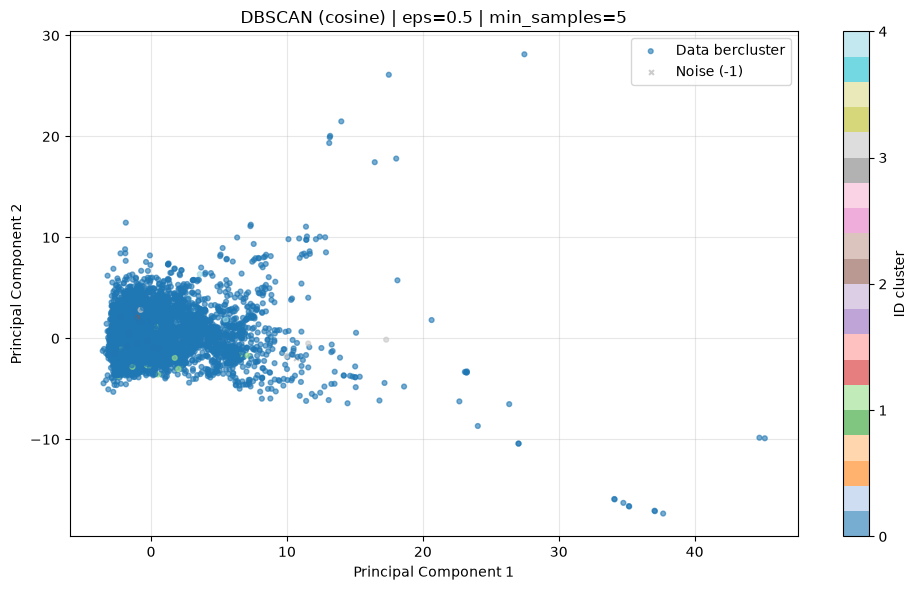

In [ ]:
pca = PCA(n_components=2, svd_solver="full", random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"Total explained variance PCA: {pca.explained_variance_ratio_.sum():.2%}")

fig, ax = plt.subplots(figsize=(10, 6))

if (~noise_mask).any():
    points = ax.scatter(
        X_pca[~noise_mask, 0],
        X_pca[~noise_mask, 1],
        c=cluster_labels[~noise_mask],
        cmap="tab20",
        s=12,
        alpha=0.6,
        zorder=2,
        label="Data bercluster"
    )
    if n_clusters > 1:
        fig.colorbar(
            points,
            ax=ax,
            label="ID cluster",
            ticks=np.unique(cluster_labels[~noise_mask]) if n_clusters <= 10 else None
        )

if noise_mask.any():
    ax.scatter(
        X_pca[noise_mask, 0],
        X_pca[noise_mask, 1],
        c="gray",
        marker="x",
        s=12,
        alpha=0.4,
        zorder=1,
        label="Noise (-1)"
    )

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title(
    f"DBSCAN ({DISTANCE_METRIC}) | eps={EPS} | min_samples={MIN_SAMPLES}"
)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()